# 🎬 Movie Recommendation System — Interactive Visualizations
**User 5 · Collaborative Filtering · MovieLens Dataset**

This notebook provides multiple interactive chart alternatives to a basic bar chart for exploring top-10 predicted movie recommendations.

In [9]:
# Install required libraries (run once)
# !pip install plotly pandas ipywidgets

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## 📦 Sample Data
Based on the top-10 recommendations for User 5 (from the original chart).

In [10]:
# Top-10 recommendations for User 5
data = {
    'Movie': [
        'Tom and Huck',
        'Circle of Friends',
        'Homeward Bound: The Incredible Journey',
        'The Third Man',
        'Tough and Deadly',
        'Charade',
        'L.A. Confidential',
        'Citizen Ruth',
        'The Inspector General',
        'Boogie Nights'
    ],
    'Year': [1995, 1995, 1993, 1949, 1995, 1963, 1997, 1996, 1949, 1997],
    'Predicted_Rating': [5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0],
    'Genre': [
        'Adventure/Family',
        'Drama/Romance',
        'Adventure/Family',
        'Film-Noir/Thriller',
        'Action/Thriller',
        'Comedy/Mystery',
        'Crime/Film-Noir',
        'Comedy/Drama',
        'Comedy/Musical',
        'Drama'
    ],
    'Primary_Genre': [
        'Adventure', 'Drama', 'Adventure', 'Thriller',
        'Action', 'Comedy', 'Crime', 'Comedy', 'Comedy', 'Drama'
    ],
    'Num_Ratings': [45, 120, 210, 380, 30, 175, 520, 60, 55, 490],
    'Avg_Global_Rating': [3.4, 3.6, 4.0, 4.4, 3.1, 4.1, 4.2, 3.3, 3.5, 3.9],
    'Rank': list(range(1, 11))
}

df = pd.DataFrame(data)
print(f'📊 Dataset: {len(df)} movies')
df.head()

📊 Dataset: 10 movies


,Movie,Year,Predicted_Rating,Genre,Primary_Genre,Num_Ratings,Avg_Global_Rating,Rank
0,Tom and Huck,1995,5.0,Adventure/Family,Adventure,45,3.4,1
1,Circle of Friends,1995,5.0,Drama/Romance,Drama,120,3.6,2
2,Homeward Bound: The Incredible Journey,1993,5.0,Adventure/Family,Adventure,210,4.0,3
3,The Third Man,1949,5.0,Film-Noir/Thriller,Thriller,380,4.4,4
4,Tough and Deadly,1995,5.0,Action/Thriller,Action,30,3.1,5


---
## 📊 Chart 1 — Horizontal Lollipop Chart
> **Why better than bar chart?** Lollipop charts reduce ink-to-data ratio and look cleaner when all values are equal. The dot markers draw the eye to the exact value without heavy bars.

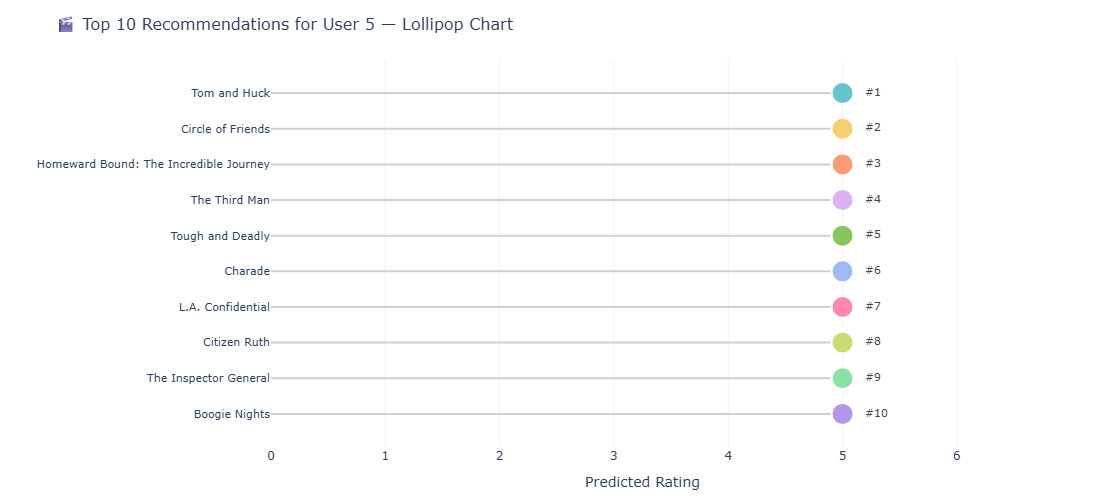

In [11]:
fig = go.Figure()

colors = px.colors.qualitative.Pastel

for i, row in df.iterrows():
    fig.add_trace(go.Scatter(
        x=[0, row['Predicted_Rating']],
        y=[row['Movie'], row['Movie']],
        mode='lines',
        line=dict(color='#d0d0d0', width=2),
        showlegend=False,
        hoverinfo='skip'
    ))
    fig.add_trace(go.Scatter(
        x=[row['Predicted_Rating']],
        y=[row['Movie']],
        mode='markers+text',
        marker=dict(size=22, color=colors[i % len(colors)], line=dict(width=2, color='white')),
        text=[f"  #{row['Rank']}"],
        textposition='middle right',
        textfont=dict(size=11, color='#444'),
        name=row['Primary_Genre'],
        hovertemplate=(
            f"<b>{row['Movie']}</b><br>"
            f"Year: {row['Year']}<br>"
            f"Genre: {row['Genre']}<br>"
            f"Predicted Rating: {row['Predicted_Rating']}<br>"
            f"Global Avg: {row['Avg_Global_Rating']}<extra></extra>"
        ),
        showlegend=False
    ))

fig.update_layout(
    title=dict(text='🎬 Top 10 Recommendations for User 5 — Lollipop Chart', font=dict(size=16)),
    xaxis=dict(title='Predicted Rating', range=[0, 6.5], gridcolor='#f0f0f0'),
    yaxis=dict(title='', autorange='reversed', tickfont=dict(size=11)),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=500,
    margin=dict(l=250, r=80, t=60, b=50)
)

fig.show()

---
## 🫧 Chart 2 — Bubble Chart: Year vs. Global Rating
> **Why better?** Since all predicted ratings are 5.0, we can add a second dimension — the movie's **global average rating** vs **release year**. Bubble size = number of ratings (popularity). Hover for full details.

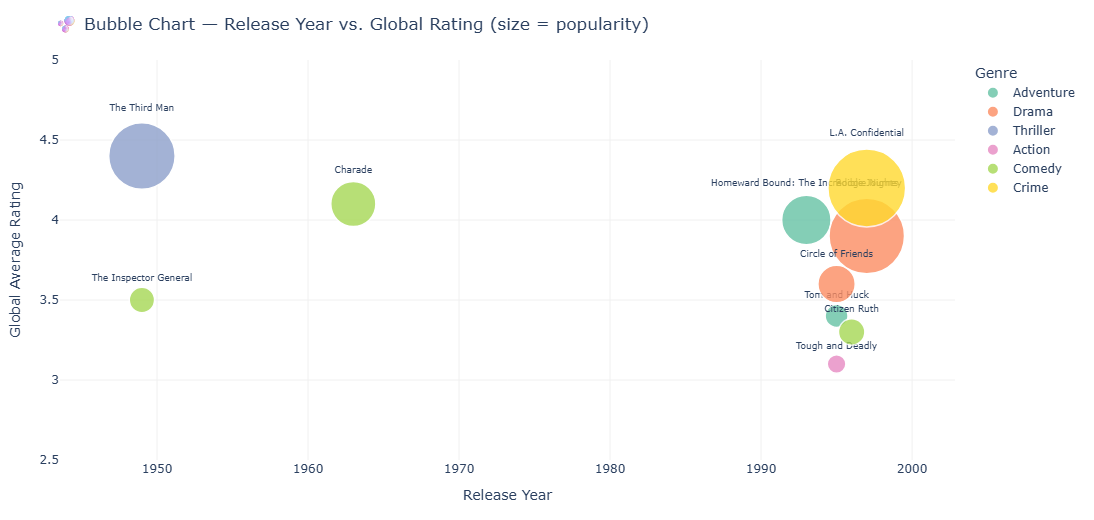

In [12]:
fig2 = px.scatter(
    df,
    x='Year',
    y='Avg_Global_Rating',
    size='Num_Ratings',
    color='Primary_Genre',
    hover_name='Movie',
    hover_data={
        'Year': True,
        'Genre': True,
        'Predicted_Rating': True,
        'Num_Ratings': True,
        'Avg_Global_Rating': ':.2f'
    },
    text='Movie',
    size_max=55,
    color_discrete_sequence=px.colors.qualitative.Set2,
    title='🫧 Bubble Chart — Release Year vs. Global Rating (size = popularity)'
)

fig2.update_traces(
    textposition='top center',
    textfont=dict(size=9),
    marker=dict(opacity=0.8, line=dict(width=1.5, color='white'))
)

fig2.update_layout(
    xaxis=dict(title='Release Year', gridcolor='#f0f0f0'),
    yaxis=dict(title='Global Average Rating', gridcolor='#f0f0f0', range=[2.5, 5.0]),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=520,
    legend=dict(title='Genre', orientation='v'),
    margin=dict(l=60, r=60, t=60, b=60)
)

fig2.show()

---
## 🎯 Chart 3 — Genre Distribution (Sunburst Chart)
> **Why better?** Shows the **genre composition** of recommendations hierarchically — useful for understanding *why* this user is getting these suggestions (their taste profile).

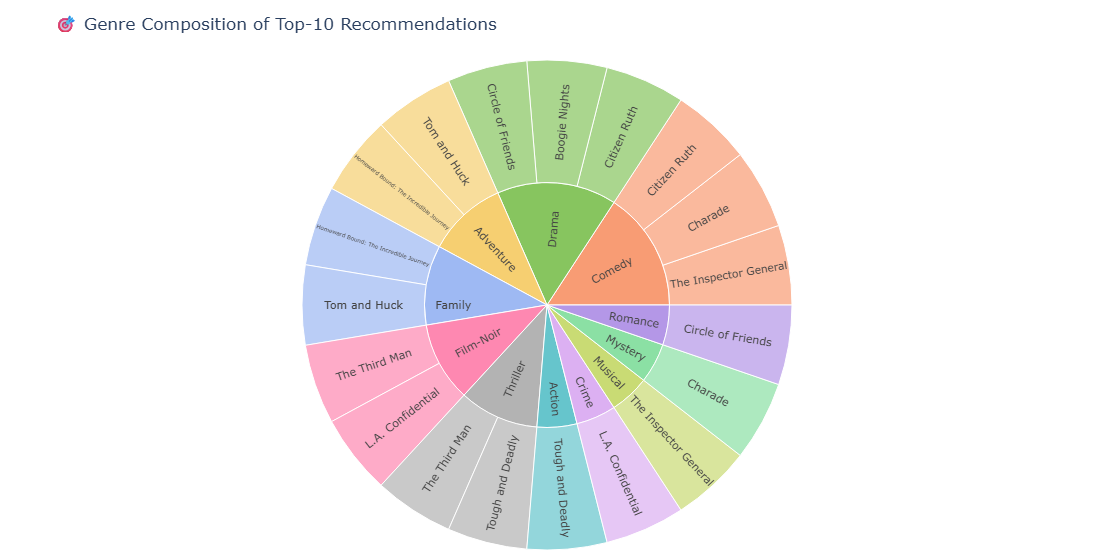

In [13]:
# Explode genres for sunburst
genre_rows = []
for _, row in df.iterrows():
    for g in row['Genre'].split('/'):
        genre_rows.append({'Movie': row['Movie'], 'Genre': g.strip(), 'Rating': row['Predicted_Rating']})

gdf = pd.DataFrame(genre_rows)

fig3 = px.sunburst(
    gdf,
    path=['Genre', 'Movie'],
    values='Rating',
    color='Genre',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    title='🎯 Genre Composition of Top-10 Recommendations'
)

fig3.update_traces(
    textfont=dict(size=11),
    insidetextorientation='radial'
)

fig3.update_layout(
    height=550,
    margin=dict(t=60, l=0, r=0, b=0)
)

fig3.show()

---
## 📊 Chart 4 — Predicted vs. Global Rating (Diverging Bar)
> **Why useful?** Compares the **model's predicted rating (5.0)** against the **real-world global average** — showing how much the model "believes" in each film vs. what others rated it. The gap reveals model confidence.

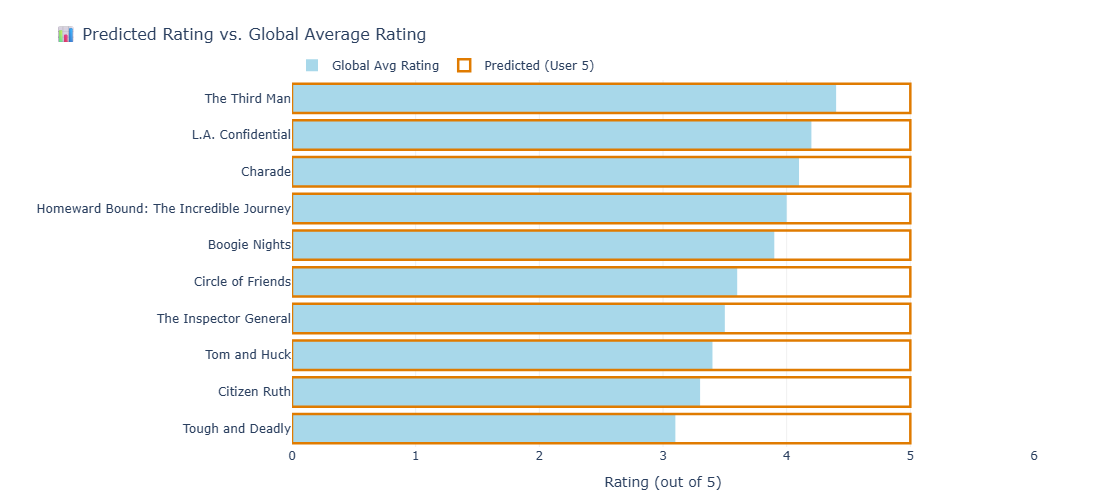

In [14]:
df_sorted = df.sort_values('Avg_Global_Rating', ascending=True)

fig4 = go.Figure()

fig4.add_trace(go.Bar(
    y=df_sorted['Movie'],
    x=df_sorted['Avg_Global_Rating'],
    name='Global Avg Rating',
    orientation='h',
    marker=dict(color='#a8d8ea', line=dict(width=0)),
    hovertemplate='<b>%{y}</b><br>Global Avg: %{x:.2f}<extra></extra>'
))

fig4.add_trace(go.Bar(
    y=df_sorted['Movie'],
    x=df_sorted['Predicted_Rating'],
    name='Predicted (User 5)',
    orientation='h',
    marker=dict(
        color='rgba(255,165,0,0.0)',
        line=dict(color='#e07b00', width=2.5)
    ),
    hovertemplate='<b>%{y}</b><br>Predicted: %{x:.1f}<extra></extra>'
))

fig4.update_layout(
    barmode='overlay',
    title=dict(text='📊 Predicted Rating vs. Global Average Rating', font=dict(size=16)),
    xaxis=dict(title='Rating (out of 5)', range=[0, 6], gridcolor='#f0f0f0'),
    yaxis=dict(title=''),
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend=dict(orientation='h', y=1.08, x=0),
    height=500,
    margin=dict(l=260, r=60, t=80, b=50)
)

fig4.show()

---
## 🕸️ Chart 5 — Radar Chart (Genre Profile)
> **Why useful?** A radar chart reveals the **taste fingerprint** of this user's recommendations — what genres dominate the top-10 list.

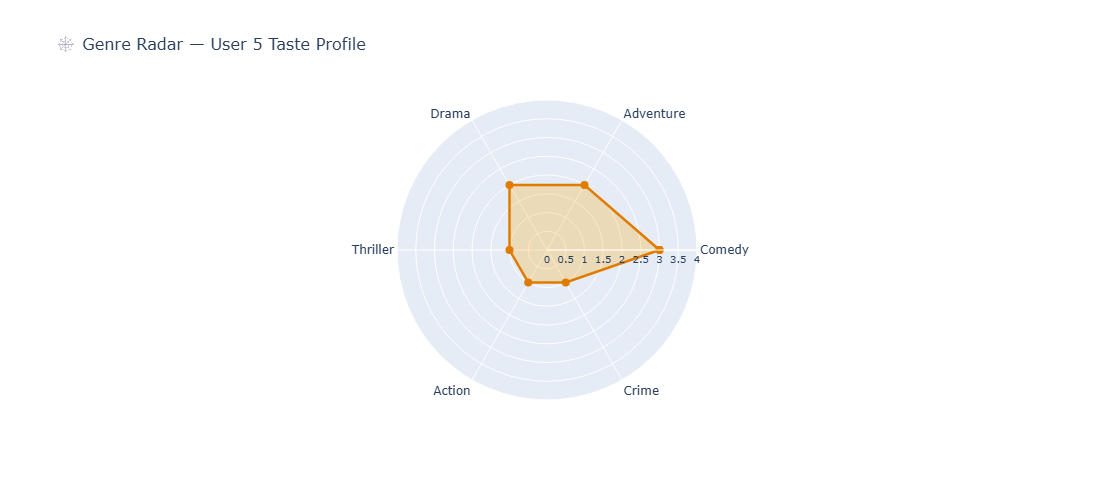

In [15]:
genre_counts = df['Primary_Genre'].value_counts()
categories = list(genre_counts.index)
values = list(genre_counts.values)
# Close the loop
categories_closed = categories + [categories[0]]
values_closed = values + [values[0]]

fig5 = go.Figure()

fig5.add_trace(go.Scatterpolar(
    r=values_closed,
    theta=categories_closed,
    fill='toself',
    fillcolor='rgba(255, 165, 0, 0.25)',
    line=dict(color='#e07b00', width=2.5),
    marker=dict(size=8, color='#e07b00'),
    name='User 5 Genre Mix',
    hovertemplate='Genre: <b>%{theta}</b><br>Count: %{r}<extra></extra>'
))

fig5.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0, max(values)+1], tickfont=dict(size=10)),
        angularaxis=dict(tickfont=dict(size=12))
    ),
    title=dict(text='🕸️ Genre Radar — User 5 Taste Profile', font=dict(size=16)),
    showlegend=False,
    height=480,
    paper_bgcolor='white'
)

fig5.show()

---
## 🔥 Bonus — Combined Dashboard
> All four key views in a single 2×2 subplot grid.

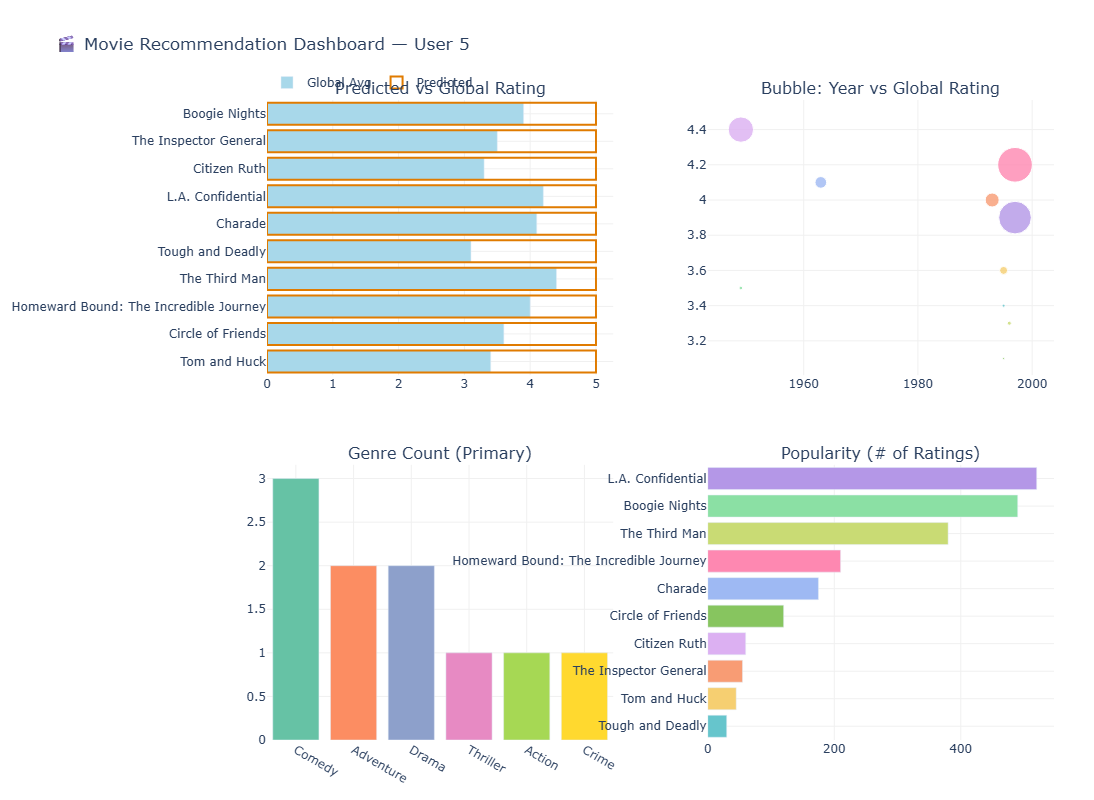

✅ Dashboard rendered!


In [16]:
from plotly.subplots import make_subplots

fig6 = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'Predicted vs Global Rating',
        'Bubble: Year vs Global Rating',
        'Genre Count (Primary)',
        'Popularity (# of Ratings)'
    ],
    vertical_spacing=0.14,
    horizontal_spacing=0.12
)

colors_list = px.colors.qualitative.Pastel[:len(df)]

# ── subplot 1: overlay bar
fig6.add_trace(go.Bar(
    y=df['Movie'], x=df['Avg_Global_Rating'],
    orientation='h', name='Global Avg',
    marker_color='#a8d8ea', showlegend=True
), row=1, col=1)
fig6.add_trace(go.Bar(
    y=df['Movie'], x=df['Predicted_Rating'],
    orientation='h', name='Predicted',
    marker=dict(color='rgba(0,0,0,0)', line=dict(color='#e07b00', width=2)),
    showlegend=True
), row=1, col=1)

# ── subplot 2: bubble
for i, row in df.iterrows():
    fig6.add_trace(go.Scatter(
        x=[row['Year']], y=[row['Avg_Global_Rating']],
        mode='markers',
        marker=dict(size=row['Num_Ratings']/15, color=colors_list[i], opacity=0.8,
                    line=dict(width=1, color='white')),
        name=row['Movie'], showlegend=False,
        hovertemplate=f"<b>{row['Movie']}</b><br>Year: {row['Year']}<br>Avg: {row['Avg_Global_Rating']}<extra></extra>"
    ), row=1, col=2)

# ── subplot 3: genre bar
gc = df['Primary_Genre'].value_counts()
fig6.add_trace(go.Bar(
    x=gc.index, y=gc.values,
    marker_color=px.colors.qualitative.Set2[:len(gc)],
    showlegend=False
), row=2, col=1)

# ── subplot 4: popularity
df_pop = df.sort_values('Num_Ratings', ascending=True)
fig6.add_trace(go.Bar(
    y=df_pop['Movie'], x=df_pop['Num_Ratings'],
    orientation='h',
    marker_color=px.colors.qualitative.Pastel[:len(df_pop)],
    showlegend=False
), row=2, col=2)

fig6.update_layout(
    title=dict(text='🎬 Movie Recommendation Dashboard — User 5', font=dict(size=17)),
    barmode='overlay',
    height=800,
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend=dict(orientation='h', y=1.05, x=0),
    margin=dict(l=200, r=40, t=100, b=60)
)

fig6.update_xaxes(gridcolor='#f0f0f0')
fig6.update_yaxes(gridcolor='#f0f0f0')

fig6.show()
print('✅ Dashboard rendered!')

---
## 🗺️ Chart 6 — Treemap (Genre → Movie, sized by Popularity)
> **Why it works well here?** Since all predicted ratings are equal (5.0), a treemap uses a *second metric* — **number of ratings (popularity)** — to size each tile. This immediately reveals which recommended movies are widely seen vs. hidden gems, grouped by genre. It's more informative than the original bar chart at a glance.

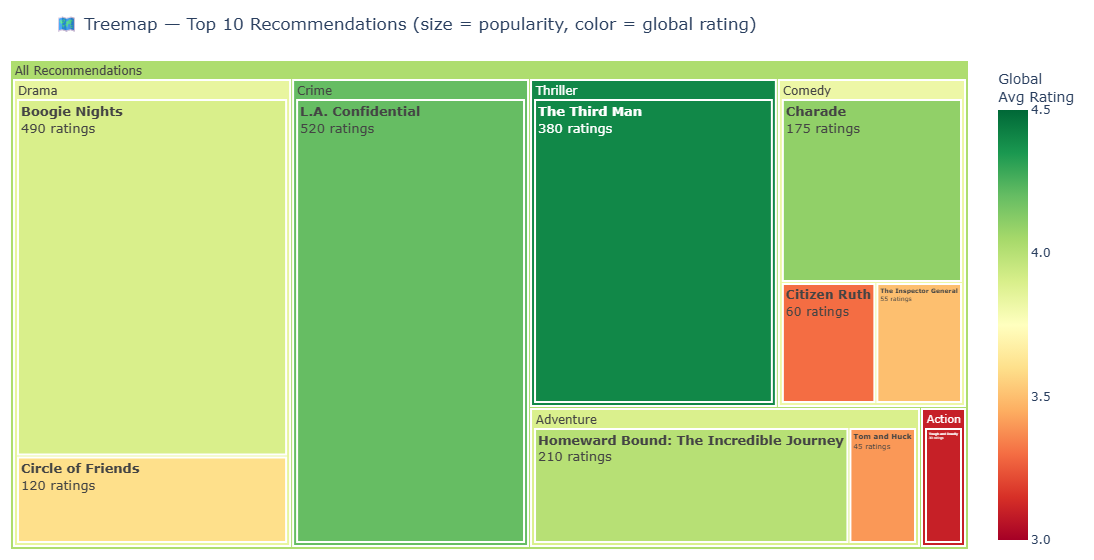

🗺️ Treemap rendered! Click genre blocks to zoom in.


In [17]:
fig7 = px.treemap(
    df,
    path=[px.Constant('All Recommendations'), 'Primary_Genre', 'Movie'],
    values='Num_Ratings',
    color='Avg_Global_Rating',
    color_continuous_scale='RdYlGn',
    range_color=[3.0, 4.5],
    hover_data={
        'Year': True,
        'Genre': True,
        'Predicted_Rating': True,
        'Avg_Global_Rating': ':.2f',
        'Num_Ratings': True
    },
    title='🗺️ Treemap — Top 10 Recommendations (size = popularity, color = global rating)'
)

fig7.update_traces(
    texttemplate='<b>%{label}</b><br>%{value} ratings',
    textfont=dict(size=13),
    marker=dict(
        line=dict(width=2, color='white'),
        pad=dict(t=20, l=4, r=4, b=4)
    ),
    hovertemplate=(
        '<b>%{label}</b><br>'
        'Popularity: %{value} ratings<br>'
        'Global Avg Rating: %{color:.2f}<br>'
        '<extra></extra>'
    )
)

fig7.update_layout(
    height=560,
    margin=dict(t=60, l=10, r=10, b=10),
    coloraxis_colorbar=dict(
        title='Global<br>Avg Rating',
        tickvals=[3.0, 3.5, 4.0, 4.5],
        ticktext=['3.0', '3.5', '4.0', '4.5']
    )
)

fig7.show()
print('🗺️ Treemap rendered! Click genre blocks to zoom in.')

### 🔍 How to read this Treemap

| Visual Element | Meaning |
|---|---|
| **Tile size** | Number of ratings = how popular the movie is globally |
| **Color (green)** | High global average rating (well-loved) |
| **Color (red)** | Lower global average rating (niche / underrated) |
| **Grouping** | Movies are clustered by primary genre |
| **Click** | Click a genre block to zoom in on its movies |

> 💡 **Key insight:** L.A. Confidential and Boogie Nights dominate by popularity, while Tom and Huck and Tough and Deadly are niche picks — yet the model predicts 5.0 for all, suggesting User 5 has eclectic taste.

---
## 📝 Summary

| Chart | Best For |
|---|---|
| **Lollipop** | Clean ranking when all scores are equal |
| **Bubble** | Multi-dimension view: year, popularity, rating |
| **Sunburst** | Genre composition / taste profile |
| **Diverging Bar** | Predicted vs. global average comparison |
| **Radar** | User's genre fingerprint |
| **Treemap** ✅ | Genre grouping + popularity + rating in one view |
| **Dashboard** | Executive overview of all dimensions |

> 💡 **Tip:** Replace the sample data in Cell 2 with your own MovieLens CSV to use this notebook on real data.